# Background and interference: controlled comparison

**Exploratory result:** the specified restricted field model fits this averaged trajectory substantially better than background only or the constant-coefficient effective-intensity version tested here. This is evidence about curve agreement, not recovery of true rod angles or proof of the interference mechanism.

## Coordinates and data

$X=(I_0-I_{90})/(I_0+I_{90})$, $Y=(I_{45}-I_{135})/(I_{45}+I_{135})$.
The earlier first-cycle maximum $Y\simeq0.54$ referred to locally averaged **raw** channel voltages. Figures here use gain- and T-corrected channels; their maxima are not directly interchangeable.

Source: `files3_first40s.tdms`, 30–31 s. The preceding repeatability study extracted 304 complete trajectories using the same crossing gate and 128 ordered, contiguous raw-channel averaging bins per trajectory. Guide smoothing determined boundaries; channel means use raw samples. Equal-cycle means avoid overweighting slow cycles. Alternate cycles give 152 training and 152 held-out cycles. No optional dynamic time warping is used. Both passes of the anisotropy trajectory remain ordered, and the fitted mechanical phase advances exactly one full revolution; this assumes the extracted full trajectory represents one mechanical revolution.

The data and calibration used here are embedded below; this notebook reruns the forward comparison without the 77 MB source file. It does not rerun raw cycle extraction.

## Common assumptions and objective

Current gains and T are fixed; NA_in=0.38, NA_out=1.3, water/oil indices 1.33/1.51. Signal coefficients include Fresnel transmission and the BFP field mapping sqrt(cos(theta_oil))/cos(theta_water). The normalized coefficients are A=0.89080598, B=0.10919402, C=0.92778057.

Each model has three cone geometry parameters, sixteen phase-registration parameters (initial phase plus fifteen positive-increment ratios), and three additive-background parameters. The latter specify total background, degree of linear polarization in [0,1], and polarization angle. Both interference alternatives add four parameters, giving 22 versus 26 joint fit parameters. A common brightness at each point is profiled from the measured total intensity: this is a comparison conditional on total intensity, not a prediction of total brightness. Held-out total intensity is likewise supplied, but cone/background/registration parameters are not refitted.

The objective is mean squared four-channel residual divided by each point's measured total intensity squared, with equal weight per ordered bin. Reported XY RMS is sqrt(mean((X_pred-X_obs)^2+(Y_pred-Y_obs)^2)); it is a secondary metric, in a common observed coordinate space. No points are dropped. This is not a calibrated noise likelihood.

## Precisely which models were tested

1. **Background only:** $I_j=S_j+B_j$, with a physically admissible common Stokes background.
2. **Effective intensity:** $I_j=S_j+B_j+c_j\sqrt{S_j}$, with four constant channel coefficients and $|c_j|\le2\sqrt{B_j}$. This is an explicit operational version of Richard's effective-intensity suggestion; it is not every possible intensity-level interference model. Independent channel coefficients need not preserve the ideal analyzer pair-sum equality.
3. **Restricted field:** one spatially uniform transverse complex field over the accepted BFP annulus, with two complex polarization amplitudes, plus the same admissible incoherent background. The cross term is computed from its overlap with the Fresnel/BFP dipole field. Circular-excitation orientation phase is retained; its magnitude is absorbed in brightness. This particular spatial mode is an assumption. It is not a general model of all scattered fields or all locations of background origin.

Total background is restricted below 95% of the smallest training total. This deliberately bounded domain prevents an arbitrarily large-background escape and gives a unique positive brightness root. **It is not a bound inferred from raw data under destructive interference.** Warm-start refits at 80% and 99% gave the same solutions; fitted fractions are 38%, 49%, 56%, respectively. Thus these particular solutions are not pressing against that cap. Other unconstrained solutions are not excluded by this study.

## Results and interpretation

| Model | Training XY RMS | Held-out XY RMS |
|---|---:|---:|
| Background only | 0.05752 | 0.06074 |
| Effective intensity | 0.05481 | 0.05823 |
| Restricted field | 0.02171 | 0.02772 |

The field model reduces held-out XY RMS by about 54% relative to background only. Increasing phase registration from 16 to 24 or 32 intervals preserves the ranking (field held-out RMS 0.0273/0.0272). Eight chronological group means also favor the field model, although those groups overlap the training set and are only a drift diagnostic.

There is still structured residual, and field-fit incoherent background polarization reaches its allowed maximum. Multiple local minima exist. Finite multistart optimization is not proof of a global optimum. Neither curve agreement nor same-recording holdout establishes correct angles, cone uniqueness, correct calibration, or the actual background field. Angle parameters should not yet be interpreted as calibrated measurements.

## Historical background-only control

Using the historical curve-matching objective on the old 90 selected points versus the new 128-point training average gives best costs 0.0076486 and 0.0076754: essentially unchanged. These costs are in the old corrected-anisotropy objective and must not be compared numerically with the new channel objective. Both historical fits exploit polarization components whose vector length exceeds one; enforcing a physical Stokes background on the new average gives 0.0087087. No negative-intensity points were silently discarded in this control.

Thus cycle extraction alone has not removed the old mismatch in this interval. It remains possible that calibration error, fixed-cone inadequacy, averaging bias, or a different field model contributes. Next useful checks are a separately selected stable interval and synthetic recovery/identifiability tests; the present comparisons do not prove true-angle recovery.


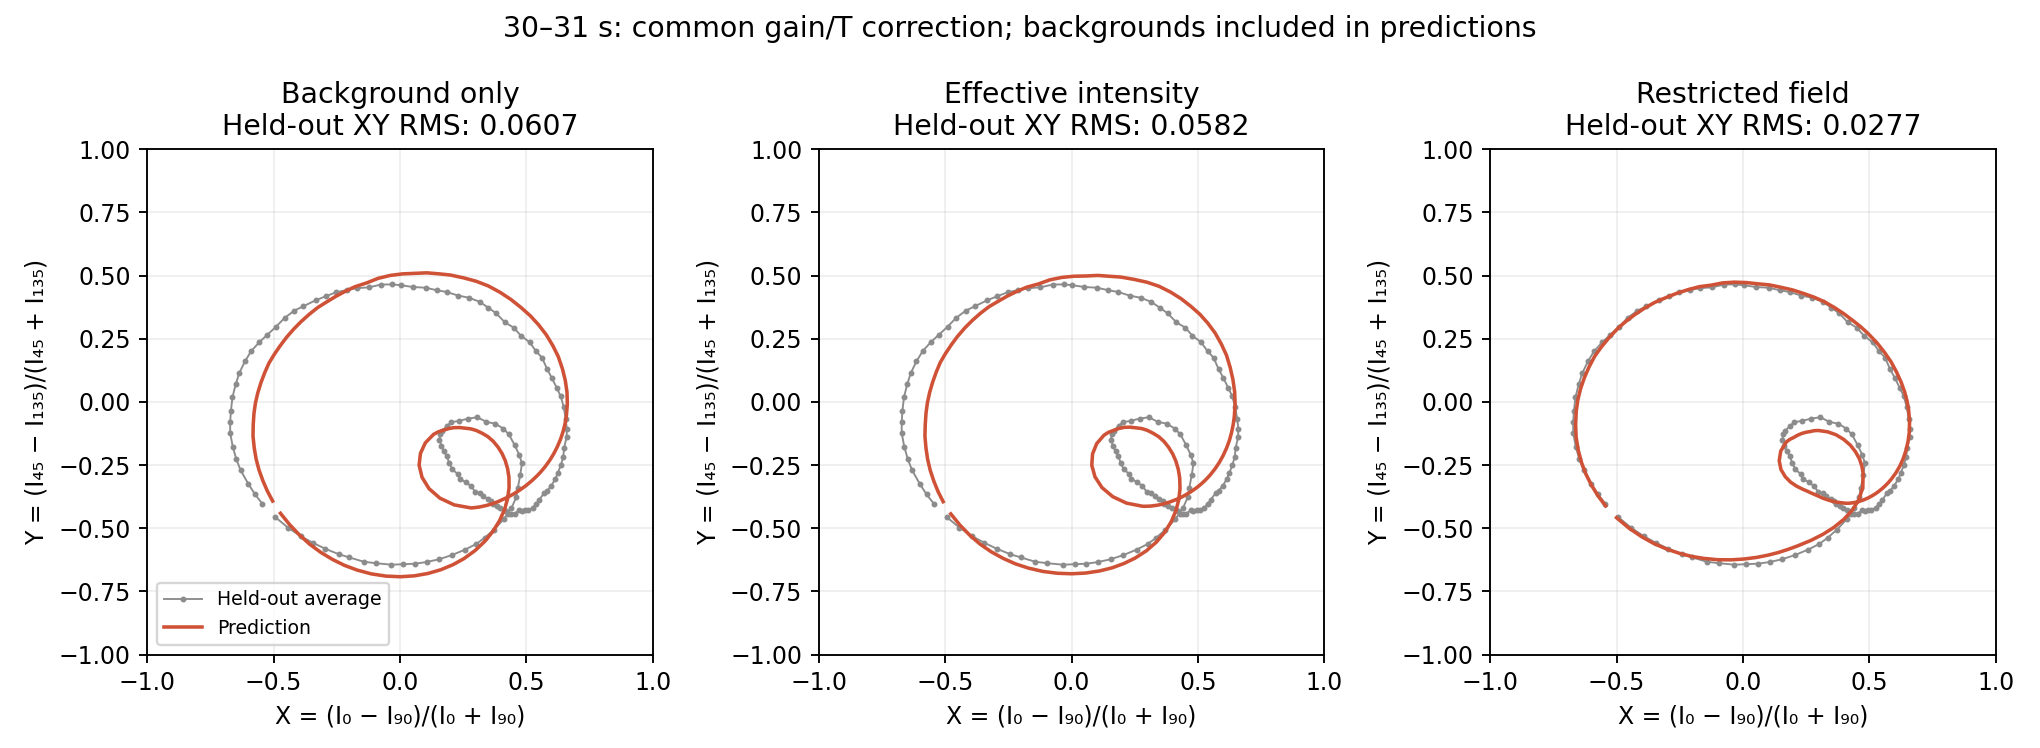

In [1]:
# Saved comparison figure; recreated by the plotting cell below.

In [ ]:
"""Forward, collected-channel models for a controlled comparison.
Fixed .38..1.3 annulus, n_water=1.33, n_oil=1.51. No matrix calibration fit.
"""
import numpy as np
from numpy.polynomial.legendre import leggauss
from scipy.special import softmax

ABC=np.array([.8908059777413628,.10919402225863714,.9277805723143716])
ANALYZERS=np.array([[1.,0.],[0.,1.],[1.,1.],[1.,-1.]])
ANALYZERS[2:]/=np.sqrt(2)

def uniform_pupil_overlap(order=128):
 x,w=leggauss(order);rho=.38+(x+1)*(1.3-.38)/2;dr=w*(1.3-.38)/2
 sw=rho/1.33;cw=np.sqrt(1-sw*sw);co=np.sqrt(1-(rho/1.51)**2)
 tp=2*1.33*cw/(1.33*co+1.51*cw);ts=2*1.33*cw/(1.33*cw+1.51*co)
 measure=2*np.pi*rho*dr
 qxx=np.sum(measure*co/cw**2*(3*(tp*cw)**2+2*tp*cw*ts+3*ts**2)/8)
 qyy=np.sum(measure*co/cw**2*(tp*cw-ts)**2/8)
 # Same normalization A+B=1 as the signal quadratic form.
 norm=(qxx+qyy)/2;area=np.pi*(1.3**2-.38**2)
 return np.sum(measure*np.sqrt(co)/cw*(tp*cw+ts)/2)/np.sqrt(area*norm)
GAMMA=uniform_pupil_overlap()

def cone(geometry,chi):
 th,ph,lam=geometry
 k=np.array([np.sin(th)*np.cos(ph),np.sin(th)*np.sin(ph),np.cos(th)])
 e1=np.array([-np.cos(th)*np.cos(ph),-np.cos(th)*np.sin(ph),np.sin(th)])
 e2=np.cross(k,e1)
 return np.cos(lam)*k+np.sin(lam)*(np.cos(chi)[:,None]*e1+np.sin(chi)[:,None]*e2)

def q_channels(d):
 A,B,C=ABC;x,y,z=d.T;s2=x*x+y*y
 return np.array([A+B*s2+C*(x*x-y*y),A+B*s2-C*(x*x-y*y),A+B*s2+2*C*x*y,A+B*s2-2*C*x*y])

def xy(c):
 return np.column_stack([(c[0]-c[1])/(c[0]+c[1]),(c[2]-c[3])/(c[2]+c[3])])

def stokes_background(total,polar,angle):
 # total is sum of four ideal-analyser intensities; pair sums are total/2.
 return total/4*np.array([1+polar*np.cos(angle),1-polar*np.cos(angle),1+polar*np.sin(angle),1-polar*np.sin(angle)])

def mechanical_phase(p,n,knots,direction):
 inc=softmax(np.r_[p[4:4+knots-1],0.])
 f=np.r_[0,np.cumsum(inc)]
 return p[3]+direction*2*np.pi*np.interp(np.arange(n)/n,np.linspace(0,1,knots+1),f)

def bounds(model,knots,cap=.95):
 lo=[.001,-np.pi,.001,-4*np.pi]+[-4.]*(knots-1)+[0.,0.,-np.pi]
 hi=[np.pi/2-.001,np.pi,np.pi/2-.001,4*np.pi]+[4.]*(knots-1)+[cap,1.,np.pi]
 if model=='richard':lo += [-1.]*4;hi += [1.]*4
 if model=='field':lo += [0.,0.,-np.pi,-np.pi];hi += [1.,np.pi/2,np.pi,np.pi]
 return np.array(lo),np.array(hi)

def predict(p,model,data,total_min,knots=16,direction=1):
 phase=mechanical_phase(p,data.shape[1],knots,direction)
 d=cone(p[:3],phase);q=q_channels(d);t=data.sum(axis=0)
 offset=knots+3
 f,pol,ang=p[offset:offset+3];btot=f*total_min
 bg=stokes_background(btot,pol,ang);linear=np.zeros_like(q)
 details={}
 if model=='richard':
  c=2*np.sqrt(bg)*p[offset+3:offset+7]
  linear=c[:,None]*np.sqrt(q);details['c']=c.tolist()
 elif model=='field':
  share,eta,rel,common=p[offset+3:offset+7]
  b=np.sqrt(btot*share/2)*np.exp(1j*common)*np.array([np.cos(eta),np.sin(eta)*np.exp(1j*rel)])
  bj=ANALYZERS@b
  bg=stokes_background(btot*(1-share),pol,ang)+np.abs(bj)**2
  # Circular excitation: orientation-dependent excitation phase is retained.
  # Its amplitude is absorbed in the common per-point brightness scale.
  exc=np.exp(1j*np.arctan2(d[:,1],d[:,0]))
  overlap=GAMMA*(ANALYZERS@d[:,:2].T)*exc[None,:]
  linear=2*np.real(overlap*np.conj(bj[:,None]))
  details.update(b_complex=[[float(v.real),float(v.imag)] for v in b],coherent_share=float(share))
 remaining=t-bg.sum();qsum=q.sum(axis=0);lsum=linear.sum(axis=0)
 # Within chosen conservative domain B_total < min observed total there is one
 # nonnegative root; no discarded data or branch-dependent positivity mask.
 disc=lsum**2+4*qsum*remaining
 z=(-lsum+np.sqrt(np.maximum(disc,0)))/(2*qsum)
 pred=q*z[None,:]**2+linear*z[None,:]+bg[:,None]
 details.update(background=bg.tolist(),total_bg=float(bg.sum()),brightness=z*z,
                theta=np.rad2deg(np.arccos(np.abs(d[:,2]))),phase=phase,
                signal=q*z[None,:]**2,cross=linear*z[None,:])
 return pred,details

def residual(p,model,data,total_min,knots=16,direction=1):
 pred,_=predict(p,model,data,total_min,knots,direction)
 return ((pred-data)/data.sum(axis=0)).ravel()


In [ ]:
import json
from scipy.optimize import least_squares
train=np.array([[0.16047373678927604, 0.1486444707615993, 0.14047120518693487, 0.1349299253181779, 0.12996550009437766, 0.12475432695600717, 0.1203088312947411, 0.11952763674992484, 0.11865682066029593, 0.11931784396783426, 0.12291780997487596, 0.1277013349136933, 0.13371452952592383, 0.13998420611105117, 0.14934419565274162, 0.15641500056515248, 0.1660698255014221, 0.17714740095814105, 0.19011238159268493, 0.20032287241798757, 0.2122575671599339, 0.22539124503134045, 0.23542811699216395, 0.25025452512884805, 0.2628983198964467, 0.2736892253581852, 0.2866307250865571, 0.29678122455704636, 0.3132540223750029, 0.32958677974593437, 0.34040057122457956, 0.3516230437993504, 0.36225387581962604, 0.37547356726359093, 0.3887808149743699, 0.4018867447786181, 0.4138528773699989, 0.42496702221249083, 0.4353099348508817, 0.4437868637677571, 0.4530493030398274, 0.46146871939025474, 0.47085077752081345, 0.4833682145094115, 0.49258754917689124, 0.49903272856279035, 0.5054835292401259, 0.5094145978784791, 0.5165927368472939, 0.518382576642791, 0.5222548392440627, 0.5251377097303447, 0.5275303735859902, 0.528458155130927, 0.527048483981295, 0.5216367661113869, 0.5187168155171301, 0.5135217749101905, 0.5096645747773104, 0.5040935697318775, 0.497300788669159, 0.49167088857150315, 0.4855312291251867, 0.48004453342537734, 0.4721754187406632, 0.4645321820581678, 0.45523282691620703, 0.44717104649409667, 0.43849508112347896, 0.4308428954336354, 0.4199309158249543, 0.40982479529019417, 0.40063771997854136, 0.3895807308502986, 0.3794918602366947, 0.3711401225601439, 0.3601080289976796, 0.34874983362604745, 0.33582812546749335, 0.3248580781970509, 0.3136038490550435, 0.3024083573346733, 0.29149051198233666, 0.28226152764098833, 0.2734874740988175, 0.2654064728120103, 0.25855796441144846, 0.25311252411140855, 0.2487249901887848, 0.24801619140711803, 0.24963406253965456, 0.2508812456941755, 0.2530149451876842, 0.2576291260219959, 0.26361045167128455, 0.2726057164832518, 0.2831155358521631, 0.2918246803947751, 0.29841762654452547, 0.308169709979786, 0.3166480161636913, 0.3255388673498003, 0.3337466657358724, 0.3408850562907891, 0.34635515541161743, 0.35278658938228313, 0.3559622226909718, 0.3573779339680342, 0.35739108647530543, 0.3546257838777331, 0.34960878639739057, 0.34594662846759094, 0.34033449126057297, 0.3341315864250874, 0.3284766075536557, 0.3211086492300223, 0.31072158593033605, 0.30011918918690245, 0.28951648984075845, 0.2772380287519491, 0.2637276968915484, 0.25538037140187014, 0.24568355755602403, 0.2321734343740749, 0.2175868059994243, 0.201566331919456, 0.18914803237146569, 0.17500150156569855], [0.5381800686799519, 0.5550216089539536, 0.5692433693094939, 0.5788988377772537, 0.5858685892649723, 0.592542769621086, 0.5979492613381656, 0.5981950785860901, 0.5983428701673748, 0.5943418891721384, 0.585407080005332, 0.5784538844993289, 0.5666860539057897, 0.5537320420811147, 0.5390306400154721, 0.5230353144069233, 0.5075250538219118, 0.4908321443272116, 0.4719357417966559, 0.45485207729855237, 0.4375508624447081, 0.423992804328201, 0.4061946896847664, 0.38792766842122767, 0.3730258948003151, 0.35523363112817014, 0.33418361541598496, 0.32229493495965994, 0.30767121780649387, 0.2884346423473727, 0.27500157583872, 0.2611028027656556, 0.24738285649952677, 0.23311371815531068, 0.22177625411574683, 0.21009348476046605, 0.19843955735376462, 0.18602928165423255, 0.17435375960231414, 0.16588385385098844, 0.15657235304311176, 0.14920544752829595, 0.1419871994931608, 0.1348684283776835, 0.12835539611757998, 0.12332740094108026, 0.11929868894952529, 0.11665144021178217, 0.11434077807270204, 0.11445580704366852, 0.11430557672167153, 0.11418846327208867, 0.11689900170691088, 0.1168087636204234, 0.1203374781493901, 0.12322115013681484, 0.12740605000716798, 0.13340927572755423, 0.13759296624384243, 0.14231862996271963, 0.14693394567828452, 0.1496443748373303, 0.15222747805138534, 0.15531883101382302, 0.15929555178687124, 0.16241937497002368, 0.16504927383589676, 0.16823471467763032, 0.172717862651551, 0.17377205671734214, 0.1765186639183543, 0.17882839287910943, 0.18155560506946836, 0.18443193223026216, 0.18346596802064843, 0.18143692134104533, 0.17981457719868607, 0.18149475453814887, 0.17964059410399744, 0.17874187714512263, 0.1801640016728313, 0.18055848034680902, 0.18299950490487607, 0.1837549121167765, 0.18302597974688448, 0.18287299797426898, 0.18316339318042416, 0.1806945644002747, 0.1795991652485395, 0.1765392372102287, 0.17349838292738765, 0.17115491777655678, 0.1675604451652032, 0.16288272561762418, 0.15743935046278498, 0.15193452070569483, 0.14555159062786022, 0.1395013230086075, 0.13452426317528313, 0.1308059982842744, 0.12764381343209086, 0.12494048752542412, 0.12225556738638495, 0.12325798401190469, 0.12564299879322313, 0.12935655931774157, 0.1344020575792612, 0.14241393082461393, 0.15270653844457738, 0.16552886267492248, 0.18140058232137232, 0.19493434204680565, 0.21191310022283463, 0.22998102104949797, 0.2476510524028944, 0.2620362842748445, 0.28157128529121245, 0.3018669479995264, 0.323141057302016, 0.3459697833829718, 0.3691311424705381, 0.3864121854414908, 0.40243161327742505, 0.42417593969513057, 0.4465005360465522, 0.4708178043984939, 0.4901319216015616, 0.5135787091936506], [0.20739497346777797, 0.2248194673417188, 0.2409636634665251, 0.2558418478811295, 0.2713861639248659, 0.2902234784192686, 0.30919204304540326, 0.32643737178565824, 0.342734262087035, 0.36135025936447807, 0.37608387601895366, 0.39091557892688683, 0.4016591114424837, 0.41099726385382834, 0.42296343801643, 0.4257547959005775, 0.4350843325465229, 0.4403491628053099, 0.44692910732439745, 0.44851772566622694, 0.4518994299920709, 0.46055621074721975, 0.4564778060235353, 0.45942127872697075, 0.4599597440785023, 0.4561306897962235, 0.4476016925474567, 0.44763541344394087, 0.4514161650396162, 0.4469868908016635, 0.44278566115534734, 0.4385738565384985, 0.43153393672853085, 0.4256965934034887, 0.42575682472459075, 0.4207627598399095, 0.414654303200929, 0.40611001890211573, 0.3954079098062609, 0.38617641138468367, 0.3782755124600234, 0.3693878906122067, 0.3611190816175558, 0.3538157162882234, 0.34330493504283416, 0.33365878248254077, 0.32042500274146424, 0.3091170151375981, 0.2977789982253624, 0.284639760287738, 0.27481626944180215, 0.2663066727095378, 0.25959285771974694, 0.24842476800225116, 0.24082179333975748, 0.23001117677733954, 0.22006758582183053, 0.21355161515135093, 0.20753179828818372, 0.2026956905872109, 0.1952863683247782, 0.19103731764005394, 0.18977942156427363, 0.18769157774074077, 0.18425641685087268, 0.18248348817328167, 0.17923687168327626, 0.1769730020826253, 0.17383128770935138, 0.1729754485097979, 0.1718195468828122, 0.17037317564759447, 0.16789260943053885, 0.16672227248997748, 0.16735813449950684, 0.16828982122286337, 0.16992439836762616, 0.16840373153092358, 0.1689595950139792, 0.1678497587254439, 0.16910485304554726, 0.16993068677224726, 0.17010784435970286, 0.1703673239268362, 0.17154197956206263, 0.17330762891600057, 0.17615424130521667, 0.1796917595093305, 0.1822906273919676, 0.18427047923748435, 0.18818578773421732, 0.1904058293475177, 0.19233154597706198, 0.19478644388462038, 0.19501519599427244, 0.19670629750697083, 0.19824902259881405, 0.19652325585631966, 0.1931883278520293, 0.19106442434778012, 0.1869162417289399, 0.1837022066256919, 0.17750309698238317, 0.1714035211311812, 0.16397538878531326, 0.1573755434580821, 0.14944333499924228, 0.14181473176082923, 0.1356747095504962, 0.12795244127447356, 0.12210573375454435, 0.11647453271572143, 0.11191362521816157, 0.10894280894506565, 0.10698851140162746, 0.10597984578293385, 0.10666491555278845, 0.10736947029330142, 0.10971984142536906, 0.11372303460406628, 0.11865725722247995, 0.12364360518055105, 0.12844805590191422, 0.13644677824302262, 0.14631101107976283, 0.15925541470231747, 0.17143067976333534, 0.18806655547819293], [0.49217234044957026, 0.48031898474052886, 0.46955008611020893, 0.459135545531754, 0.44518122490351536, 0.42830985432353247, 0.41103654168470577, 0.3931766281294007, 0.3735585230626271, 0.352729833037631, 0.33345198455701697, 0.3143644674413635, 0.2991460969864794, 0.28292305229748876, 0.26482025115911684, 0.2515888056956598, 0.23761044224993078, 0.2251858799649781, 0.21271315765329507, 0.20352774347896904, 0.19535818297623234, 0.18786922962755295, 0.18143889882542694, 0.1735374212035898, 0.17026655687790782, 0.16757740346592176, 0.16587353099484112, 0.16392183973124763, 0.1628602245179728, 0.16341180192094198, 0.1646404046507691, 0.16659332051041012, 0.1699295883673022, 0.1740655935639376, 0.1787531843848476, 0.1829121602843335, 0.1893393902497017, 0.19622983729281449, 0.20630255796964658, 0.21413930930363967, 0.22437727623489953, 0.23266034815029937, 0.2440869646777672, 0.2555760405084926, 0.26948508179315345, 0.28075616675858134, 0.29653086702661063, 0.31050781346355966, 0.3264845743402076, 0.3425822605999606, 0.35476376264099824, 0.36748492303488717, 0.3793623589522882, 0.3928032294964787, 0.40137068430775524, 0.4101726468646492, 0.4211665489663623, 0.42988686602052273, 0.43649930261170367, 0.44031622680779625, 0.4451456173105631, 0.4475573236829405, 0.4457014245109908, 0.44534274395174767, 0.4444486632978327, 0.44286238403793127, 0.4395227412003103, 0.436140239018802, 0.4354373234611247, 0.42981396903120767, 0.42339450942366197, 0.4174198963529476, 0.4138069051441732, 0.4062090803342564, 0.3953816139169384, 0.3847527563526717, 0.3714772844791986, 0.36234969177203563, 0.3482588932622691, 0.3364635793409736, 0.326592318646665, 0.3158314089905794, 0.30776131251557853, 0.2985657663633901, 0.28714903100031425, 0.27883489242227366, 0.2693999672992087, 0.25823043018305025, 0.25071161000858233, 0.24453436142426743, 0.2387252147160698, 0.2355538407552995, 0.23188317680958528, 0.2291068387416419, 0.22896308904128865, 0.23027603222314347, 0.23249491668700786, 0.23662848032177317, 0.24071440548553466, 0.24825071364906542, 0.2567459761432325, 0.2666530183407891, 0.2774631619919827, 0.29058037747443255, 0.30600443352775974, 0.3210334106042717, 0.33703355208576824, 0.3546692971130302, 0.3712850172589263, 0.38876708298447776, 0.40669078356565, 0.4196133219920198, 0.43641466105597904, 0.45060113968825294, 0.4647005412782623, 0.4729678157147389, 0.48272558103188984, 0.4927778259868627, 0.5006258195233723, 0.508723983783376, 0.5131744267324255, 0.5167785885365409, 0.518266522922006, 0.5197094665564318, 0.5189815156091788, 0.5142849330644454, 0.5087853360456029, 0.5026876297554345]])
test=np.array([[0.1589282970564348, 0.150065494350634, 0.14139300031069488, 0.13156901368191598, 0.12599165047961783, 0.12112766375854019, 0.1176828270986599, 0.11715478770098536, 0.11802046736780693, 0.1196886409259057, 0.12363699579070438, 0.12768243675156826, 0.13477339078565842, 0.1426959210675319, 0.1522122587731892, 0.16082429618624242, 0.17145618640684743, 0.1811391602875032, 0.19219580612759832, 0.20218871320467927, 0.21614977697469126, 0.22631090859265723, 0.23802611088931916, 0.24937550274974593, 0.2609305854897402, 0.2722617343611099, 0.28842586359645245, 0.30093233259961116, 0.30917040168475934, 0.3205313063805163, 0.3364224170673062, 0.34786976959479304, 0.36074429784231127, 0.3731647054957471, 0.3878592631951805, 0.40111863751208615, 0.41009225380559916, 0.41793579842661277, 0.42707594502526436, 0.4387897836285239, 0.4482954275512617, 0.4613609908387662, 0.4699414235151164, 0.48094811979263147, 0.4856234123715045, 0.4943606620476827, 0.5041931471415576, 0.5128554982514821, 0.5173015391870447, 0.5221568754870584, 0.5261447937351423, 0.5302920492397479, 0.5280066824016455, 0.5282159956346999, 0.5252337442034115, 0.5235422276693013, 0.5214642671614008, 0.5163298343348128, 0.5122335071658709, 0.5069082464053435, 0.5003518059403805, 0.49413517008934704, 0.48877116883084976, 0.4810340896583242, 0.47385113649895705, 0.46612897294765676, 0.45926729822720264, 0.4510047528037779, 0.4425329815218676, 0.4345293538504855, 0.42737468466184786, 0.4171459551825106, 0.40698956473046577, 0.39682729558627416, 0.3849146086483504, 0.3767641535116241, 0.3658716545575831, 0.35320263339455343, 0.3420291196638012, 0.3299440933079685, 0.3185267790934029, 0.3073709362415824, 0.29612149505845314, 0.28804806396009774, 0.27729438671911105, 0.268829531637972, 0.26141418501517383, 0.25518902611814437, 0.25012016550912836, 0.24625782444473485, 0.24382356406944267, 0.2450019196335779, 0.2489440834094924, 0.2515073363285451, 0.257342763287534, 0.26766226813673416, 0.277185030782897, 0.28724216710494965, 0.30032292024394563, 0.3109477685256562, 0.3193688809463106, 0.3294903768606978, 0.33829002494370547, 0.34618293143843254, 0.34899934103508945, 0.3532545730000235, 0.3589008248149531, 0.36027100500419706, 0.3622926021112017, 0.35944242870044774, 0.3557457512431426, 0.3521627843287237, 0.34619363446643103, 0.337340826682521, 0.3304704000274535, 0.32102400606312353, 0.31304536385049103, 0.30443818549081714, 0.29529114582781907, 0.28073162208165114, 0.27048125862282113, 0.25589826054684994, 0.24561110323623145, 0.23090068769447064, 0.2173778560037194, 0.2035333794937435, 0.1890406849591203, 0.17430290683926453], [0.5394358923207424, 0.5538982054831275, 0.5660976751447214, 0.5808596944293675, 0.5895472824391599, 0.5956955900656006, 0.6000919097947373, 0.5973438475142592, 0.5952133162235197, 0.590878890778732, 0.5836076904086411, 0.5746726114435387, 0.562946408343796, 0.5520272061080128, 0.5336166245633948, 0.5175737505929437, 0.5013064759342242, 0.48523890868720937, 0.46820985475101223, 0.45239011996482137, 0.4331086537330062, 0.41391349332273153, 0.3983221243352237, 0.38282674593303834, 0.3682681042318718, 0.3488147939645621, 0.3347978331919216, 0.32026944655069106, 0.30723422757303903, 0.28975430623210685, 0.27432560658040683, 0.2600347975609075, 0.24853101961195634, 0.23378744356789674, 0.22106134643302627, 0.2091324671213414, 0.19758453336772258, 0.18753127330772706, 0.1765752812615453, 0.1666015311002934, 0.15844007328777127, 0.14852908434843462, 0.140939991750027, 0.13498432494542295, 0.1284993135550239, 0.12318658135774617, 0.11852345579896444, 0.11428739743500357, 0.1105255848536275, 0.10881149652974653, 0.10779311469265734, 0.10904723717978602, 0.11238260580677657, 0.11359536419754072, 0.11675387188350383, 0.12114810175603401, 0.12476388475310053, 0.12982109225822877, 0.13532210500090774, 0.13889062103431032, 0.14512379561510022, 0.14844081967132794, 0.15242189570083942, 0.15687103238380842, 0.16032312308842364, 0.1629110612699497, 0.16491555160785637, 0.16983291135266015, 0.1721294688417315, 0.17396765202414946, 0.17427888862290494, 0.17361495531806165, 0.17612766022562446, 0.17704172202001073, 0.17847474661146076, 0.17715702986920565, 0.17767306748256254, 0.17790333401539787, 0.17783700797302524, 0.17862295176627296, 0.17893755203075631, 0.18024783163761982, 0.1826965417923579, 0.1812053056504492, 0.18217069028360203, 0.1812901512450943, 0.17977937424297688, 0.1795901659760588, 0.1798534719083149, 0.1800504968810903, 0.17678665031018329, 0.17470249062967452, 0.170362753571378, 0.16688413292214363, 0.15988360319527306, 0.1541110007365834, 0.14739255996049178, 0.14095040670909575, 0.1358260384747371, 0.13059894705578878, 0.12706660963366484, 0.12405494412950949, 0.12141967697930652, 0.12088889462595194, 0.12415970682212688, 0.12866298195072562, 0.13295078202997077, 0.1399092519734222, 0.15160601228630433, 0.16469830307382635, 0.1775420302784759, 0.18906979600271004, 0.20411265134152892, 0.2223301008094766, 0.24222246125472918, 0.2601418006910114, 0.27868649038905763, 0.29677677034548366, 0.3160160102084977, 0.34098851676335623, 0.3612700485493446, 0.3844874551748007, 0.4021965633048373, 0.424909584593613, 0.4463362172029884, 0.4675280905535139, 0.4905122302292261, 0.5156746206257714], [0.20868610174772526, 0.22331647563869195, 0.23978071604533618, 0.2608787535912023, 0.277713351540479, 0.2958781881050671, 0.3157392026606883, 0.3296465221105662, 0.344768223777613, 0.3624577013255559, 0.3781398226901239, 0.39109714933288453, 0.40547359715528597, 0.4168176659484614, 0.42434247047847246, 0.4287531154216722, 0.4354410099157961, 0.4425958432112736, 0.44731951614596577, 0.4490533801299227, 0.45274353934100214, 0.45242720886632815, 0.4530356971467659, 0.4522867430380057, 0.45200204311800213, 0.44724611121687224, 0.45225951224560346, 0.450077263471706, 0.44496007815085986, 0.43861270607285796, 0.4381167699267536, 0.43233175226970033, 0.43033406221511344, 0.4260364172028533, 0.4251477634368383, 0.4208306541500646, 0.411458797944104, 0.40290627182524735, 0.39024132061897143, 0.38570135462965655, 0.3771135725879824, 0.37106346416818003, 0.36115972564959253, 0.35668794195768283, 0.34256372441033406, 0.33315634265047855, 0.3251413094487838, 0.31701040223260796, 0.3041071354606788, 0.2922031526419277, 0.27993136520752454, 0.27233081463292697, 0.2596331249853968, 0.24958572224680015, 0.23928187890149824, 0.22991874027103842, 0.22313203440948667, 0.21465756746252299, 0.2087569254775471, 0.20570123099649637, 0.1962027952793358, 0.19045925099686242, 0.18550674098599249, 0.1818184118238376, 0.18126293987700426, 0.17848107539779012, 0.17773385348772078, 0.17254145048270866, 0.17033378469174826, 0.1689699784864186, 0.16999662315841169, 0.1691497766729225, 0.16916207763600455, 0.1686651295445427, 0.16757048428936208, 0.16832974885400373, 0.16759135794553598, 0.16681648763680515, 0.16634003321668062, 0.16456881885191652, 0.1667933432516953, 0.16679716132791278, 0.16748473068648867, 0.16900270691650293, 0.16938708174866318, 0.1723672177722361, 0.1748958955923788, 0.1767365072681948, 0.1793259468555693, 0.18275570649452055, 0.18514434462648494, 0.18790951542981973, 0.191753887370561, 0.1940126724594119, 0.1947169274668311, 0.19822128189632787, 0.2008739953119116, 0.197964503781407, 0.1998103701530109, 0.19848168543417558, 0.19462629442519083, 0.18809056913725444, 0.1810690675773779, 0.17614788267077758, 0.16715802339451152, 0.15864259220903146, 0.15202298242286724, 0.14409893195941614, 0.13667848596268672, 0.1287176790188637, 0.1222001323077611, 0.11761568104538184, 0.11346273857957655, 0.10939321205835524, 0.1070128719618425, 0.10598129098452069, 0.10597280891646188, 0.10710425951429203, 0.10842833458286001, 0.11227914207268751, 0.11548998370648823, 0.12277585378616597, 0.1279053037914728, 0.13699038102275723, 0.146838198910869, 0.1569509842049651, 0.17076996425747182, 0.18865516932938875], [0.4901192337599007, 0.48106824343871546, 0.46996093647826787, 0.454604630786508, 0.44063903760226447, 0.42258661312791546, 0.4042657468724802, 0.38610440712576183, 0.36911793262302894, 0.34956842117968323, 0.32908199187234827, 0.31147163795511273, 0.293178142895041, 0.27746822002850563, 0.2616223234004878, 0.24906276399774752, 0.23555991369747326, 0.22151102175948054, 0.20983778993782148, 0.20228371823619376, 0.1930892615186111, 0.18545196990664, 0.17880651989072952, 0.17465843666659495, 0.17145325317122526, 0.16820789348223542, 0.16541158531113861, 0.16437432545444997, 0.16378917419461841, 0.164424892432168, 0.16540594196799, 0.16725818299933892, 0.1694161742520027, 0.1736580332859766, 0.17705801135868024, 0.18197618981986616, 0.18808141169639034, 0.1938808343653104, 0.20336165819652438, 0.21042308157979184, 0.22023091778851725, 0.22952453182299162, 0.24079826576880708, 0.25025112976736397, 0.2635339936347799, 0.2759881235548449, 0.29015701689831674, 0.30279520541414107, 0.31740417494037226, 0.33346417566330877, 0.346988117373251, 0.36093195485856355, 0.37522192414854433, 0.3870986096653506, 0.39865526447662736, 0.4097289177316221, 0.4195139680549273, 0.4275812229472635, 0.4347167681497275, 0.43720825060883384, 0.4452944931594311, 0.44882948717605986, 0.452837374436511, 0.45304174803058833, 0.45033927938557844, 0.44885701513017334, 0.444649805272777, 0.44578629225831545, 0.44226277119762886, 0.438311950847951, 0.42966711789761997, 0.421100483801723, 0.41398288079319906, 0.40401027269560336, 0.39627287151652957, 0.3855705560666339, 0.3763848791266704, 0.3644505826587501, 0.35529446648716734, 0.3464991863802635, 0.3328815458163748, 0.3226673137146602, 0.31354093150985496, 0.30350079850778905, 0.29294384410318774, 0.2821161380903521, 0.27082570242223947, 0.2626099118614383, 0.25413793236646354, 0.24702899725024516, 0.23971284498825685, 0.2359382551694472, 0.23138342068339574, 0.2278391405125048, 0.22627756699833917, 0.22628081937392644, 0.22676654656976727, 0.23191261554162812, 0.23748287776032362, 0.24518569690464184, 0.25220239523089033, 0.26513736760902357, 0.2771795458020647, 0.2892822800595781, 0.30441279765904244, 0.32144090082786425, 0.33647520160176897, 0.3534289219895034, 0.3736311917182634, 0.3915237430926182, 0.40675824097670826, 0.41949055960502496, 0.4319995957334645, 0.44558458103806464, 0.46010542004976, 0.4723632886716547, 0.4829609891573646, 0.49137079055286886, 0.5008096772305621, 0.5080336553884521, 0.5127362109300693, 0.5152082455006157, 0.5161849061444174, 0.516900136925313, 0.516707446724819, 0.5122229497176554, 0.5086491352768834, 0.5035075297697054]])
TMIN=float(train.sum(axis=0).min())
saved={'bg': {'p': [0.5101350495078775, -1.9247722338928237, 0.9098081540638026, 3.8462941867187452, -0.25266058387494433, -0.3361935816886056, -0.32004167307053366, -0.15018415323432877, -0.015808317199438506, 0.05015616973739818, -0.2981045086311277, -0.9815398297704587, -1.186971489527479, -0.92845959747567, 0.7962116715420621, -0.012562486337172878, 0.13003640425150506, 0.27643267022927265, 0.14677538658990152, 0.3804225373321262, 0.7571262219034707, -0.819644041112558], 'direction': -1, 'cost': 0.00010417654716293338, 'success': True, 'message': '`ftol` termination condition is satisfied.', 'nfev': 25, 'seconds': 0.07394266128540039, 'train': {'xy_rms': 0.05752024499768413, 'normalized_channel_rms': 0.010206691293604082, 'pair_imbalance_pred_rms': 4.6425270586831154e-17, 'background_total_fraction_of_minimum': 0.3804225373321262, 'folded_theta_range_deg': [22.971332528046137, 81.35607178735005]}, 'test': {'xy_rms': 0.06074049352591771, 'normalized_channel_rms': 0.010776749866431994, 'pair_imbalance_pred_rms': 4.693603887794959e-17, 'background_total_fraction_of_minimum': 0.3804225373321262, 'folded_theta_range_deg': [22.971332528046137, 81.35607178735005]}, 'jac_singular_values': [5.446066884513249, 3.171468840613256, 2.850957654406175, 1.5766020808952528, 1.0074300418965494, 0.8043803677802728, 0.5317095019900219, 0.4153285104672043, 0.2935342836522571, 0.2832190320796992, 0.21521306529713513, 0.19337315623972265, 0.1706801501858854, 0.14638773478152597, 0.1352055045007188, 0.11744226938007399, 0.11097566209141992, 0.09005867284833703, 0.06502705805558211, 0.056372792460755626, 0.0453687651214425, 0.03469460340032687]}, 'richard': {'p': [0.5085230037530383, -1.9125945097872068, 0.9060054108109664, 3.8240330146776227, -0.2663268259967355, -0.3551502555468192, -0.32286508357396276, -0.18377377402229542, -0.012710191303085271, 0.07043274750699596, -0.2753704560913433, -0.9594290510329954, -1.1697695644508403, -0.9918783542450177, 0.7627851762150951, 0.03785237992189363, 0.13415982997048162, 0.30620052994027797, 0.12315782550347906, 0.4858865548936426, 0.4638180839087784, -0.8971626728652083, -0.10000794579558525, -0.2478090434107223, -0.24772307956041179, -0.12566244372211566], 'direction': -1, 'cost': 9.782072295357465e-05, 'success': True, 'message': '`ftol` termination condition is satisfied.', 'nfev': 28, 'seconds': 0.1076817512512207, 'train': {'xy_rms': 0.05480619215650714, 'normalized_channel_rms': 0.009890435933444726, 'pair_imbalance_pred_rms': 0.009864153905415566, 'background_total_fraction_of_minimum': 0.48588655489364263, 'folded_theta_range_deg': [22.816788122129953, 81.04304274630148]}, 'test': {'xy_rms': 0.0582271372189809, 'normalized_channel_rms': 0.010453962268108036, 'pair_imbalance_pred_rms': 0.009871116155885661, 'background_total_fraction_of_minimum': 0.48588655489364263, 'folded_theta_range_deg': [22.816788122129953, 81.04304274630148]}, 'jac_singular_values': [5.4517000270393305, 3.7031167535018445, 3.3840544306519966, 2.7522997141880183, 2.4720138471464495, 1.9229792028012525, 0.8812677926944018, 0.5284113278705498, 0.4216775299094343, 0.3451999198829193, 0.29259912691587203, 0.284775199615081, 0.2154097678548228, 0.18895458716012925, 0.16914816087918277, 0.15838814587964137, 0.14633975405431507, 0.1374320168584794, 0.1226399117070997, 0.1140950514539025, 0.09549379363949403, 0.08924094215893336, 0.06823503340336406, 0.054839448291686195, 0.04523789970181987, 0.03380340514105083]}, 'field': {'p': [0.46648452994392836, -1.9746091244466144, 0.8570295363915041, 3.41654103879364, -0.3106475158103585, -0.49111248475751235, -0.6441373638703258, -0.6854301815919823, -0.6778765412091546, -0.4207626437047939, -0.25426540985719115, -0.5949785683268952, -0.5439537355195087, 0.24151957048508277, 0.3723570481095786, -0.69101315738652, 0.07069401094174982, 0.7978208715472606, 0.21664164527515264, 0.5559976317563491, 0.9999999998224325, 0.5528516143228357, 0.6499195390501032, 0.44935648295881553, -2.2146305389472993, -1.7689657617375911], 'direction': -1, 'cost': 1.4913801226033133e-05, 'success': True, 'message': '`ftol` termination condition is satisfied.', 'nfev': 35, 'seconds': 0.16380906105041504, 'train': {'xy_rms': 0.021714273057905176, 'normalized_channel_rms': 0.003861839098931121, 'pair_imbalance_pred_rms': 8.272584187737854e-17, 'background_total_fraction_of_minimum': 0.5559976317563491, 'folded_theta_range_deg': [22.410251062027925, 75.83101033396841]}, 'test': {'xy_rms': 0.02771687360073203, 'normalized_channel_rms': 0.004937250459988854, 'pair_imbalance_pred_rms': 9.155757983186672e-17, 'background_total_fraction_of_minimum': 0.5559976317563491, 'folded_theta_range_deg': [22.410251062027925, 75.83101033396841]}, 'jac_singular_values': [7.121104722402706, 3.326940961513669, 2.9955499192918036, 2.332846194253915, 1.7354606697936623, 0.9246199354541772, 0.7375653025162937, 0.5681574856287772, 0.415992121236914, 0.3343628983142709, 0.21522938120033028, 0.20483507440149498, 0.18628255389957246, 0.16846076075173033, 0.13983245039711184, 0.1354512820737743, 0.12132636337107129, 0.11083727754855088, 0.08847245245925162, 0.07916502182950991, 0.058525826836639316, 0.05005000083918767, 0.04329040049346742, 0.03779074095225365, 0.022461809359233312, 0.012884184536841451]}}
sensitivity={'cap0.8_k16': {'bg': {'p': [0.5101327072177657, -1.924772255335291, 0.9098052518198488, 3.8462946258956023, -0.2526602720032283, -0.33619262208363576, -0.32004107520105746, -0.1501838259242617, -0.015808565563241287, 0.05015545522046477, -0.2981065629708564, -0.9815394743754676, -1.1869715947547033, -0.9284434957053864, 0.7962120517721808, -0.01257199917808113, 0.13003733705435377, 0.2764321873947695, 0.1467756578079233, 0.3804194840157645, 0.7571344466861923, -0.8196445937138954], 'direction': -1, 'cost': 0.00010417654715854472, 'success': True, 'message': '`ftol` termination condition is satisfied.', 'nfev': 2, 'seconds': 0.01100611686706543, 'train': {'xy_rms': 0.057520243442750536, 'normalized_channel_rms': 0.010206691293389093, 'pair_imbalance_pred_rms': 4.701532497104074e-17, 'background_total_fraction_of_minimum': 0.3804194840157645, 'folded_theta_range_deg': [22.971308297409568, 81.35577128239211]}, 'test': {'xy_rms': 0.06074051983688343, 'normalized_channel_rms': 0.010776754772112, 'pair_imbalance_pred_rms': 4.8985897901978404e-17, 'background_total_fraction_of_minimum': 0.3804194840157645, 'folded_theta_range_deg': [22.971308297409568, 81.35577128239211]}, 'jac_singular_values': [5.446067172415264, 3.1714822318480187, 2.8509682494885142, 1.5766101087261206, 1.0074331793230318, 0.8043806682538551, 0.5317094689094933, 0.41532878878079227, 0.2935346697957802, 0.28321920597774664, 0.21521303053522414, 0.193373243995064, 0.1706800632193707, 0.14638708075458487, 0.13520531521090293, 0.11744167145082543, 0.11097519251659405, 0.09005830554612888, 0.06502652933443788, 0.05637308975363043, 0.04536880585803698, 0.03469476646781609]}, 'richard': {'p': [0.5085255127205802, -1.9125930233801436, 0.9060075378592866, 3.8240309152118934, -0.26632713483614356, -0.35515211720037715, -0.322865648214494, -0.18377458187672735, -0.012710522446999705, 0.0704323665792967, -0.275370343962677, -0.9594322084182476, -1.169766547558841, -0.9918936145143907, 0.7627833471667971, 0.037856735116827155, 0.13415754032289764, 0.30620085618013915, 0.12315821995226434, 0.4858892654230453, 0.4638166810224434, -0.897158159522316, -0.10001018346572195, -0.2478093184001239, -0.247723995130202, -0.12566371935701734], 'direction': -1, 'cost': 9.782072295078997e-05, 'success': True, 'message': '`ftol` termination condition is satisfied.', 'nfev': 2, 'seconds': 0.021528005599975586, 'train': {'xy_rms': 0.05480620657535698, 'normalized_channel_rms': 0.00989043593330395, 'pair_imbalance_pred_rms': 0.00986409173182629, 'background_total_fraction_of_minimum': 0.48588926542304534, 'folded_theta_range_deg': [22.81676480158746, 81.04330909189659]}, 'test': {'xy_rms': 0.0582271481125877, 'normalized_channel_rms': 0.010453962272747905, 'pair_imbalance_pred_rms': 0.009871053973433368, 'background_total_fraction_of_minimum': 0.48588926542304534, 'folded_theta_range_deg': [22.81676480158746, 81.04330909189659]}, 'jac_singular_values': [5.451701280757249, 3.703118700273668, 3.3840637913721396, 2.7522961191104423, 2.4720188097604208, 1.9229750180635075, 0.8812688885646501, 0.5284118497736743, 0.42167802508864016, 0.3452018721660926, 0.2925991790164224, 0.28477511043260856, 0.21540990374930072, 0.188954678852668, 0.16914828748262803, 0.158388742988037, 0.14634031824103602, 0.13743205609215117, 0.12264057098284518, 0.11409513967912603, 0.09549427252339997, 0.08924140539890561, 0.0682352245692486, 0.0548390870992516, 0.045237921924908615, 0.03380327025909344]}, 'field': {'p': [0.4664856403748096, -1.9746040211706162, 0.8570313013982754, 3.416535034605569, -0.3106503426255202, -0.4911143770113048, -0.6441395289535328, -0.6854322808834605, -0.677878608342513, -0.42076470864836396, -0.25426855227175404, -0.5949810876042785, -0.5439591142857292, 0.2415171332217414, 0.3723568686243196, -0.6910154844470285, 0.07068892078497652, 0.7978235802374565, 0.2166424219967875, 0.5559979770564905, 0.9999999999981443, 0.5528466589682902, 0.6499181480012415, 0.4493586932450253, -2.2146272478980693, -1.7689653222569157], 'direction': -1, 'cost': 1.4913801225030673e-05, 'success': True, 'message': '`ftol` termination condition is satisfied.', 'nfev': 5, 'seconds': 0.03940320014953613, 'train': {'xy_rms': 0.021714274668539355, 'normalized_channel_rms': 0.0038618390988013306, 'pair_imbalance_pred_rms': 7.395059176905974e-17, 'background_total_fraction_of_minimum': 0.5559979770564905, 'folded_theta_range_deg': [22.410292964835758, 75.83117411078202]}, 'test': {'xy_rms': 0.02771687843228739, 'normalized_channel_rms': 0.004937251044590149, 'pair_imbalance_pred_rms': 5.858953941580516e-17, 'background_total_fraction_of_minimum': 0.5559979770564905, 'folded_theta_range_deg': [22.410292964835758, 75.83117411078202]}, 'jac_singular_values': [7.121110869366374, 3.3269391774355928, 2.995548262493978, 2.3328447884883086, 1.7354557723251902, 0.9246198654696197, 0.73756586750776, 0.5681583915481175, 0.41599238687623097, 0.3343630239754436, 0.21522962127303133, 0.2048351297356365, 0.1862830032606814, 0.16846100115096488, 0.13983269061717096, 0.1354512972723963, 0.12132663956292511, 0.11083734504274492, 0.08847246737185202, 0.07916506566053384, 0.05852580299262899, 0.050050083060698164, 0.043290405923615285, 0.03779082756817797, 0.022461969415605913, 0.012884247626671359]}}, 'cap0.99_k16': {'bg': {'p': [0.5101327072177657, -1.924772255335291, 0.9098052518198488, 3.8462946258956023, -0.2526602720032283, -0.33619262208363576, -0.32004107520105746, -0.1501838259242617, -0.015808565563241287, 0.05015545522046477, -0.2981065629708564, -0.9815394743754676, -1.1869715947547033, -0.9284434957053864, 0.7962120517721808, -0.01257199917808113, 0.13003733705435377, 0.2764321873947695, 0.1467756578079233, 0.3804194840157645, 0.7571344466861923, -0.8196445937138954], 'direction': -1, 'cost': 0.00010417654715854472, 'success': True, 'message': '`ftol` termination condition is satisfied.', 'nfev': 2, 'seconds': 0.01233530044555664, 'train': {'xy_rms': 0.057520243442750536, 'normalized_channel_rms': 0.010206691293389093, 'pair_imbalance_pred_rms': 4.701532497104074e-17, 'background_total_fraction_of_minimum': 0.3804194840157645, 'folded_theta_range_deg': [22.971308297409568, 81.35577128239211]}, 'test': {'xy_rms': 0.06074051983688343, 'normalized_channel_rms': 0.010776754772112, 'pair_imbalance_pred_rms': 4.8985897901978404e-17, 'background_total_fraction_of_minimum': 0.3804194840157645, 'folded_theta_range_deg': [22.971308297409568, 81.35577128239211]}, 'jac_singular_values': [5.446067172415264, 3.1714822318480187, 2.8509682494885142, 1.5766101087261206, 1.0074331793230318, 0.8043806682538551, 0.5317094689094933, 0.41532878878079227, 0.2935346697957802, 0.28321920597774664, 0.21521303053522414, 0.193373243995064, 0.1706800632193707, 0.14638708075458487, 0.13520531521090293, 0.11744167145082543, 0.11097519251659405, 0.09005830554612888, 0.06502652933443788, 0.05637308975363043, 0.04536880585803698, 0.03469476646781609]}, 'richard': {'p': [0.5085255127205802, -1.9125930233801436, 0.9060075378592866, 3.8240309152118934, -0.26632713483614356, -0.35515211720037715, -0.322865648214494, -0.18377458187672735, -0.012710522446999705, 0.0704323665792967, -0.275370343962677, -0.9594322084182476, -1.169766547558841, -0.9918936145143907, 0.7627833471667971, 0.037856735116827155, 0.13415754032289764, 0.30620085618013915, 0.12315821995226434, 0.4858892654230453, 0.4638166810224434, -0.897158159522316, -0.10001018346572195, -0.2478093184001239, -0.247723995130202, -0.12566371935701734], 'direction': -1, 'cost': 9.782072295078997e-05, 'success': True, 'message': '`ftol` termination condition is satisfied.', 'nfev': 2, 'seconds': 0.017206907272338867, 'train': {'xy_rms': 0.05480620657535698, 'normalized_channel_rms': 0.00989043593330395, 'pair_imbalance_pred_rms': 0.00986409173182629, 'background_total_fraction_of_minimum': 0.48588926542304534, 'folded_theta_range_deg': [22.81676480158746, 81.04330909189659]}, 'test': {'xy_rms': 0.0582271481125877, 'normalized_channel_rms': 0.010453962272747905, 'pair_imbalance_pred_rms': 0.009871053973433368, 'background_total_fraction_of_minimum': 0.48588926542304534, 'folded_theta_range_deg': [22.81676480158746, 81.04330909189659]}, 'jac_singular_values': [5.451701280757249, 3.703118700273668, 3.3840637913721396, 2.7522961191104423, 2.4720188097604208, 1.9229750180635075, 0.8812688885646501, 0.5284118497736743, 0.42167802508864016, 0.3452018721660926, 0.2925991790164224, 0.28477511043260856, 0.21540990374930072, 0.188954678852668, 0.16914828748262803, 0.158388742988037, 0.14634031824103602, 0.13743205609215117, 0.12264057098284518, 0.11409513967912603, 0.09549427252339997, 0.08924140539890561, 0.0682352245692486, 0.0548390870992516, 0.045237921924908615, 0.03380327025909344]}, 'field': {'p': [0.4664856457558977, -1.9746039973563432, 0.8570313078396481, 3.4165350092064726, -0.3106503480150469, -0.49111435196605197, -0.6441395179167124, -0.6854322761547414, -0.6778785999388066, -0.42076470550637296, -0.25426854195550563, -0.594981195265881, -0.5439590701512276, 0.24151717431573685, 0.3723568094484854, -0.6910151957968157, 0.07068882474620193, 0.797823593192385, 0.21664249746602926, 0.5559979747953308, 0.9999999999981439, 0.5528466216439563, 0.6499181395580674, 0.4493587055273212, -2.2146272266052303, -1.7689653256551723], 'direction': -1, 'cost': 1.491380122503398e-05, 'success': True, 'message': '`ftol` termination condition is satisfied.', 'nfev': 5, 'seconds': 0.05205392837524414, 'train': {'xy_rms': 0.021714274687564674, 'normalized_channel_rms': 0.0038618390988017586, 'pair_imbalance_pred_rms': 6.901380955567147e-17, 'background_total_fraction_of_minimum': 0.5559979747953308, 'folded_theta_range_deg': [22.410293004467086, 75.83117478443161]}, 'test': {'xy_rms': 0.027716878785474245, 'normalized_channel_rms': 0.004937251102278183, 'pair_imbalance_pred_rms': 6.938643367787484e-17, 'background_total_fraction_of_minimum': 0.5559979747953308, 'folded_theta_range_deg': [22.410293004467086, 75.83117478443161]}, 'jac_singular_values': [7.121110883720951, 3.326939145029958, 2.995548290128734, 2.3328447683867846, 1.7354557302509828, 0.9246198809005566, 0.7375658784553212, 0.5681583798259343, 0.4159923784307209, 0.33436301360533865, 0.21522960884726255, 0.20483512099451065, 0.1862830103719009, 0.1684609906289426, 0.13983269294278167, 0.1354513199703398, 0.12132664468565756, 0.11083735444596658, 0.08847246274248796, 0.07916505937859897, 0.05852582607009587, 0.050050099273380416, 0.04329040600674533, 0.03779081385152357, 0.022461971084751814, 0.012884243020529424]}}, 'cap0.95_k24': {'bg': {'p': [0.507471571226506, -1.925073398332945, 0.9049045482492533, 3.842712833211216, -0.3196925585936005, -0.3016527693795972, -0.40872492165455276, -0.34999095130199215, -0.30103261706399315, -0.1485939028672545, -0.06513650719665047, -0.0364551677775724, 0.03210549036218459, -0.31475941787556155, -0.5594275390439695, -1.234742864249073, -1.14801788589065, -1.1530240758312864, -0.8757042199029188, 0.8227955884215873, 0.3271553467859834, -0.09440709213343558, 0.11159605394530446, 0.1313113415795163, 0.266741033031317, 0.1532504964803213, -0.03300562049453703, 0.37555668723747565, 0.7740225326348742, -0.817235731296554], 'direction': -1, 'cost': 0.00010434209995455689, 'success': True, 'message': '`ftol` termination condition is satisfied.', 'nfev': 25, 'seconds': 0.2579331398010254, 'train': {'xy_rms': 0.05757410318929306, 'normalized_channel_rms': 0.01021479808682271, 'pair_imbalance_pred_rms': 4.7060699397041856e-17, 'background_total_fraction_of_minimum': 0.37555668723747565, 'folded_theta_range_deg': [22.774036413210847, 80.92281463561505]}, 'test': {'xy_rms': 0.060908687992256065, 'normalized_channel_rms': 0.010805980645550536, 'pair_imbalance_pred_rms': 4.442190037664261e-17, 'background_total_fraction_of_minimum': 0.37555668723747565, 'folded_theta_range_deg': [22.774036413210847, 80.92281463561505]}, 'jac_singular_values': [5.392839541041198, 3.184400662029407, 2.8668829136736935, 1.559645318082889, 0.9618590062036291, 0.7792036015110978, 0.44609216987267425, 0.3703541042766014, 0.24960003012358611, 0.24698982004145686, 0.18318904398927452, 0.17084101778340552, 0.14481308612593277, 0.13809306726245607, 0.11579350449635264, 0.11431586864117001, 0.09665981366580009, 0.08600205761864964, 0.0803582101240591, 0.0739100070177781, 0.06772801941548887, 0.06351871495735237, 0.05797486137556038, 0.057729428911821985, 0.051838331902260434, 0.038135002617569, 0.035792220564075175, 0.023984994211307863, 0.0219503715622714, 0.0175582930851402]}, 'richard': {'p': [0.5086165360896305, -1.9126262859272014, 0.9052123091724704, 3.819531916674398, -0.3393948089279008, -0.3202981336971161, -0.4314835060943379, -0.36289004624412163, -0.3084809221788661, -0.19255672167207394, -0.08005368647458992, -0.002506403899781282, 0.03439122659241981, -0.2917130427253784, -0.5359332498264593, -1.222291395305383, -1.1434572120511202, -1.1592384853382551, -0.9513628811163186, 0.7396726973512342, 0.4142763687096946, -0.07905263296219409, 0.11930289018873179, 0.1407023912901924, 0.29321100793753585, 0.12433852458629646, -0.05140937250577121, 0.4864897291095326, 0.4627906464118268, -0.8942256789074645, -0.10100939804655425, -0.25057011648981653, -0.24983175968660307, -0.12692016928477], 'direction': -1, 'cost': 9.797877943145306e-05, 'success': True, 'message': '`ftol` termination condition is satisfied.', 'nfev': 25, 'seconds': 0.2730703353881836, 'train': {'xy_rms': 0.05479032655038936, 'normalized_channel_rms': 0.009898423078018694, 'pair_imbalance_pred_rms': 0.009920225666284147, 'background_total_fraction_of_minimum': 0.4864897291095326, 'folded_theta_range_deg': [22.73843431489774, 81.00246807684603]}, 'test': {'xy_rms': 0.05830032298803276, 'normalized_channel_rms': 0.010477370592407059, 'pair_imbalance_pred_rms': 0.00992726923560032, 'background_total_fraction_of_minimum': 0.4864897291095326, 'folded_theta_range_deg': [22.73843431489774, 81.00246807684603]}, 'jac_singular_values': [5.401896647512524, 3.6960898670329145, 3.3850791545507377, 2.746502918371068, 2.4664741021193834, 1.9086332815419553, 0.8167093595016145, 0.4499526624007195, 0.3875479726678089, 0.32886918269387244, 0.25565150324890423, 0.2425099572028736, 0.18351379716024682, 0.16837419411941837, 0.15488001899208378, 0.14609734939294122, 0.1393874079378082, 0.11972345659165912, 0.11435268663298866, 0.10109525454370309, 0.09128285306454735, 0.0856482179808192, 0.08073257232600742, 0.0735341637858361, 0.06848939865481626, 0.06611764317975946, 0.05939207330048474, 0.05805019211851092, 0.05163116046732552, 0.03829981270002774, 0.0346581504709457, 0.023521686306494823, 0.02195888057662562, 0.017203241111625727]}, 'field': {'p': [0.4577878087790308, -2.040365594361339, 0.8377469869776023, 3.480717160588795, -0.3644660550089128, -0.3970209798676942, -0.5743583353415913, -0.6377762817989113, -0.7142572653051118, -0.7107193297697878, -0.7018131876266345, -0.6394372268490179, -0.35107560786355174, -0.31982505649604054, -0.29932451755808637, -0.7560172536352149, -0.4867863973896814, -0.14290656208124203, 0.24894065124470574, 0.5134708324681039, -0.58946274706751, -0.5448692652705444, -0.08786651769340911, 0.5258041355900044, 0.7096021679221389, 0.23863590145590913, -0.05219347533005135, 0.5593895699650618, 0.9999999999999999, 0.616357850056039, 0.6680157570305951, 0.4197538589416391, -2.2730163094925033, -1.777200927576051], 'direction': -1, 'cost': 1.3851160639823841e-05, 'success': True, 'message': '`ftol` termination condition is satisfied.', 'nfev': 23, 'seconds': 0.28507232666015625, 'train': {'xy_rms': 0.020882057291119797, 'normalized_channel_rms': 0.003721714744553086, 'pair_imbalance_pred_rms': 6.295891944527295e-17, 'background_total_fraction_of_minimum': 0.5593895699650618, 'folded_theta_range_deg': [21.778515415247774, 74.226517149748]}, 'test': {'xy_rms': 0.027293392473261343, 'normalized_channel_rms': 0.004869563596649582, 'pair_imbalance_pred_rms': 6.272759275993653e-17, 'background_total_fraction_of_minimum': 0.5593895699650618, 'folded_theta_range_deg': [21.778515415247774, 74.226517149748]}, 'jac_singular_values': [7.002948429038294, 3.3867668215028535, 3.0014100260282692, 2.340786642660089, 1.793926955064723, 0.8528447271767445, 0.6968534623779925, 0.529024411689396, 0.37121393137653863, 0.2810137839343111, 0.18572303119037747, 0.1735400124282657, 0.16508428852647947, 0.143817287330777, 0.1204948689461998, 0.11620085330026633, 0.10432289299238945, 0.09338502037286733, 0.08492020091957986, 0.07848287893355889, 0.07138325080494762, 0.06890009318966185, 0.063157505303815, 0.06254839094150644, 0.057699693308786194, 0.05123386290707769, 0.04857639829169957, 0.03902416790874457, 0.03183626868094584, 0.02774133013089159, 0.024189699767168775, 0.021435102675007207, 0.01645423824468921, 0.011697095572153204]}}, 'cap0.95_k32': {'bg': {'p': [0.5122496254811737, -1.924616611514574, 0.9133815622097778, 3.839106464188222, -0.38635499379024346, -0.3462150571363523, -0.38304558364301206, -0.46488297924941047, -0.39244099264521337, -0.3866052702743275, -0.280987920298322, -0.18524003153502455, -0.13823482185674413, -0.062412372422750856, -0.0925957980482593, -0.006861712799779283, -0.33449778119567536, -0.5315434790659216, -0.7559456552842772, -1.4150023859281864, -1.2184179140291125, -1.0799019722889684, -1.4351498405693135, -0.6179702989648289, 0.5532951748162966, 0.8885079961895541, -0.5235066684784201, 0.07646688421393073, 0.01947171111866167, 0.04920454649079379, 0.12821376183617766, 0.2371553845186594, 0.05880930390024241, 0.07507085517300191, -0.17790233601317815, 0.38386586146148466, 0.7457866526995105, -0.8204649122060006], 'direction': -1, 'cost': 0.00010342420993341807, 'success': True, 'message': '`ftol` termination condition is satisfied.', 'nfev': 24, 'seconds': 0.2590291500091553, 'train': {'xy_rms': 0.05731292543469826, 'normalized_channel_rms': 0.010169769413974836, 'pair_imbalance_pred_rms': 4.8401033045436235e-17, 'background_total_fraction_of_minimum': 0.38386586146148466, 'folded_theta_range_deg': [23.04356863020978, 81.6821386026605]}, 'test': {'xy_rms': 0.060579499667237684, 'normalized_channel_rms': 0.01074807153982387, 'pair_imbalance_pred_rms': 5.1780764417734066e-17, 'background_total_fraction_of_minimum': 0.38386586146148466, 'folded_theta_range_deg': [23.04356863020978, 81.6821386026605]}, 'jac_singular_values': [5.373772696926585, 3.1306149894843838, 2.8311631911954853, 1.5280957612865724, 0.9230954867391256, 0.756460877381208, 0.40023788814858324, 0.3359604926803795, 0.21971078765194438, 0.21838459186944995, 0.16180227989514254, 0.15383652844072002, 0.13531144086101785, 0.1255490258171847, 0.1103271632576236, 0.10271703482119723, 0.08907408099791612, 0.08063576305255461, 0.07351976148645734, 0.06937269515291852, 0.06682962059515807, 0.06258552098203579, 0.058949014316515766, 0.05373417702584169, 0.05203628123251338, 0.04864374902576384, 0.04494134549218717, 0.04414083827897872, 0.04300001530707702, 0.03862600215800358, 0.033960948997393825, 0.03207736947908933, 0.028410386888519164, 0.020157335053367337, 0.01838742813457507, 0.013970987813959118, 0.012632491584568915, 0.01087026251347149]}, 'richard': {'p': [0.5122667189381287, -1.912206768454752, 0.9124194002845585, 3.816386556532572, -0.4021587375365458, -0.36092428765165374, -0.40042626539589565, -0.48388437820716, -0.403073093098136, -0.3913595505994895, -0.2960913252669081, -0.22908117399154138, -0.16052327119912332, -0.03199750312725106, -0.07011087033370948, -0.0029909311056707105, -0.3108782614611246, -0.5029234258364976, -0.7347979112326483, -1.4002965239608351, -1.2094729126687092, -1.0789850668220446, -1.4635093539706876, -0.6719856480334103, 0.45175498119350144, 0.9103739472096243, -0.4315788268254794, 0.0907989890415113, 0.02963413458196798, 0.056233676753230856, 0.14948773154478068, 0.2648756254082858, 0.039137155036002236, 0.044331376362490016, -0.17589107135477325, 0.49064994128941436, 0.45497034743565656, -0.8997591073613707, -0.0989353454149828, -0.2435952618161312, -0.24347976537269686, -0.1247937129565355], 'direction': -1, 'cost': 9.698469697874436e-05, 'success': True, 'message': '`ftol` termination condition is satisfied.', 'nfev': 25, 'seconds': 0.3478095531463623, 'train': {'xy_rms': 0.05456225873416481, 'normalized_channel_rms': 0.009848080877955074, 'pair_imbalance_pred_rms': 0.009946780863409636, 'background_total_fraction_of_minimum': 0.49064994128941436, 'folded_theta_range_deg': [23.015300558896413, 81.62451238096226]}, 'test': {'xy_rms': 0.05801934660641024, 'normalized_channel_rms': 0.010416900979881218, 'pair_imbalance_pred_rms': 0.009953616917230214, 'background_total_fraction_of_minimum': 0.49064994128941436, 'folded_theta_range_deg': [23.015300558896413, 81.62451238096226]}, 'jac_singular_values': [5.384435640790759, 3.679940583005125, 3.376400561851976, 2.7272914032412388, 2.4696375661671737, 1.8944354970112587, 0.7778695770661608, 0.41758299977376967, 0.37156662710108307, 0.30799600386006576, 0.22825112813507853, 0.21411007036974072, 0.1634781435959774, 0.15275713156457574, 0.14932775190187048, 0.13833240048868228, 0.12559042049367117, 0.11168541342281627, 0.10385488295826219, 0.09713633579498272, 0.08688831509359314, 0.08045639089670788, 0.0738738994953709, 0.07036168373312204, 0.06652099720216904, 0.06278473635382197, 0.05849167437251172, 0.05356910572645127, 0.05173678936491679, 0.04855237607999655, 0.04485768596933299, 0.044059090119394136, 0.04279409855410819, 0.03874672635314215, 0.03293882261779674, 0.03189900887317265, 0.02806775256993567, 0.01992999596545483, 0.01953888833460775, 0.014089251347507634, 0.012476239745610315, 0.01055645001079033]}, 'field': {'p': [0.4609867731404978, -2.020799188349286, 0.8439451790660271, 3.457569799438607, -0.4213633487459848, -0.4094115687564757, -0.5022008817215595, -0.633905408395777, -0.6583951106516143, -0.7527945457888278, -0.7436920375955337, -0.7555150396113391, -0.7662767780200703, -0.6819472063497727, -0.6263248701649958, -0.34701989719809667, -0.37445262728572704, -0.363140854663371, -0.4203308862812112, -0.9210360106157263, -0.5664637399076767, -0.2724097170328982, -0.13174156148996174, 0.28968117379657216, 0.4538017481410496, 0.052793802356247505, -1.0810603259994378, -0.41311438518302684, -0.1981293858900115, 0.20272671095887407, 0.6775970383892554, 0.6491895934045143, 0.20002659552669033, 0.0955349613186038, -0.17441067514850433, 0.5599535862669277, 0.9999999999999999, 0.6012644516219868, 0.6623667983700849, 0.42855565911488785, -2.261181018182202, -1.7739269778034954], 'direction': -1, 'cost': 1.357049262716663e-05, 'success': True, 'message': '`ftol` termination condition is satisfied.', 'nfev': 31, 'seconds': 0.3716392517089844, 'train': {'xy_rms': 0.02067192618035716, 'normalized_channel_rms': 0.0036838149556087407, 'pair_imbalance_pred_rms': 6.449985929470922e-17, 'background_total_fraction_of_minimum': 0.5599535862669277, 'folded_theta_range_deg': [21.946098273829605, 74.76709008331976]}, 'test': {'xy_rms': 0.02717270135621222, 'normalized_channel_rms': 0.004846918259269029, 'pair_imbalance_pred_rms': 6.76303135143885e-17, 'background_total_fraction_of_minimum': 0.5599535862669277, 'folded_theta_range_deg': [21.946098273829605, 74.76709008331976]}, 'jac_singular_values': [6.993634856209941, 3.3740217079280597, 2.9869107136197672, 2.330522786005127, 1.7716707797354565, 0.8217530812111657, 0.6671927413260631, 0.516085542664673, 0.34863801553183543, 0.2483561222039506, 0.1694815798171841, 0.15594172885759477, 0.15126720352715645, 0.13005206560957255, 0.11161183867692089, 0.10456130121864711, 0.09753819419736562, 0.0852657199272149, 0.07926436791580038, 0.07239590586063432, 0.06660911333999181, 0.06525626195988883, 0.058618500299105744, 0.05646009046242467, 0.0519179120151192, 0.049877868265253644, 0.04729281609737417, 0.045850667170990095, 0.04352620428425692, 0.041524713071107215, 0.03981511070057736, 0.03838307252516214, 0.034146209614066635, 0.032598913921866854, 0.03159564593694767, 0.025196245693850775, 0.021064968765588474, 0.018098998976892558, 0.01498409223809659, 0.013424272896471568, 0.012742002990368472, 0.011396314041247333]}}}
historical_control={'old_selected': {'best': {'p': [23.714059274487973, 61.32499868219645, 48.255813492333985, 0.10015366319672389, 0.6575485776348717, -0.9999999857591025], 'cost': 0.007648611377395654, 'success': True}, 'runs': [{'p': [23.716926581900374, -118.23993088658365, 48.22766455660329, 0.09998385255837437, 0.6589645039798904, -0.9999998582703189], 'cost': 0.007650507859978454, 'success': True}, {'p': [23.714059274487973, 61.32499868219645, 48.255813492333985, 0.10015366319672389, 0.6575485776348717, -0.9999999857591025], 'cost': 0.007648611377395654, 'success': True}]}, 'averaged': {'best': {'p': [24.47962577884609, -106.33558622960383, 44.96097402243942, 0.09159213566463179, 0.9783838269202505, -0.9999999871960292], 'cost': 0.0076754385832681765, 'success': True}, 'runs': [{'p': [24.47962577884609, -106.33558622960383, 44.96097402243942, 0.09159213566463179, 0.9783838269202505, -0.9999999871960292], 'cost': 0.0076754385832681765, 'success': True}, {'p': [24.48060482648477, 73.66445792558802, 44.961800265996736, 0.09159763595137231, 0.9783461595718008, -0.9999999598368436], 'cost': 0.00767543859927528, 'success': True}]}, 'averaged_physical': {'best': {'p': [26.311891556704197, -105.9312989654542, 47.48480693720816, 0.12401820813160024, 0.6960836161944541, -0.7179606775844907], 'cost': 0.008708670778151986, 'success': True}, 'runs': [{'p': [26.314684729673946, 74.48708765655795, 47.45862364547686, 0.12383424131388611, 0.6971319219136132, -0.7169428702368218], 'cost': 0.008709284847322751, 'success': True}, {'p': [26.311891556704197, -105.9312989654542, 47.48480693720816, 0.12401820813160024, 0.6960836161944541, -0.7179606775844907], 'cost': 0.008708670778151986, 'success': True}]}}


In [ ]:
# Rerun from saved best solutions. All parameters are trained only on train.
refits={}
for model,best in saved.items():
    lo,hi=bounds(model,16,.95)
    f=least_squares(residual,np.clip(best['p'],lo+1e-9,hi-1e-9),
        args=(model,train,TMIN,16,best['direction']),bounds=(lo,hi),
        max_nfev=650,ftol=2e-9,xtol=2e-9,gtol=2e-9,x_scale='jac')
    refits[model]=f.x
    for name,data in [('train',train),('held out',test)]:
        pred,_=predict(f.x,model,data,TMIN,16,best['direction'])
        error=np.sqrt(np.mean(np.sum((xy(pred)-xy(data))**2,axis=1)))
        print(model,name,round(error,6))


In [ ]:
import matplotlib.pyplot as plt
fig,axes=plt.subplots(1,3,figsize=(12,4))
for ax,(model,best) in zip(axes,saved.items()):
    pred,_=predict(refits[model],model,test,TMIN,16,best['direction'])
    ax.plot(*xy(test).T,'.-',color='.6',label='Held out')
    ax.plot(*xy(pred).T,lw=1.5,label='Prediction')
    ax.set(xlim=(-1,1),ylim=(-1,1),xlabel='X',ylabel='Y',title=model)
    ax.set_aspect('equal');ax.legend();ax.grid(alpha=.2)
plt.tight_layout();plt.show()
